# Biscuit classification

The aim of this notebook is to classify biscuits using the dunking data. I first use PCA only as an exploratory check, then compare a few simple supervised models. The final method is hard-coded as a neural network, and the final evaluation uses the original dunking variables rather than PCA scores.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, scale
from sklearn.svm import SVC

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)


## Loading the data

The dunking dataset contains the labelled biscuit examples. The microscopy data is loaded later, after the final model has been trained, because it is the dataset I want to classify.


In [16]:
dunk = pd.read_csv('dunking-data.csv')
micro = pd.read_csv('microscopy-data.csv')

dunk.head()


,gamma,phi,eta,L,t,biscuit
0,0.073897,1.333006,0.000999,0.011196,19.362214,Digestive
1,0.080946,1.476758,0.001012,0.005894,11.852589,Digestive
2,0.087408,1.477141,0.000984,0.009249,24.793669,Digestive
3,0.070793,1.502001,0.001002,0.003774,16.292780,Hobnob
4,0.058917,1.548274,0.001004,0.002291,13.662271,Hobnob


## Exploratory PCA

PCA is useful here as a quick visual check, but I do not use the PCA components for the final classification. The final neural network is trained on the original variables: `gamma`, `phi`, `eta`, `L`, and `t`.


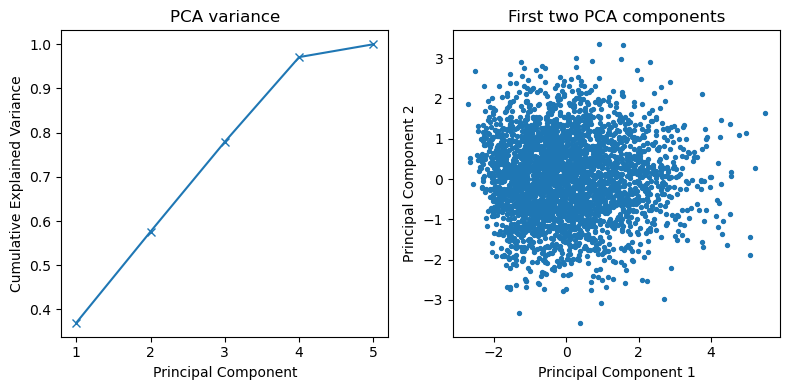

In [17]:
feature_cols = ['gamma', 'phi', 'eta', 'L', 't']

scaled_data = scale(dunk[feature_cols])
pca = PCA(n_components=5)
pca_5 = pca.fit_transform(scaled_data)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(np.arange(1, 6), np.cumsum(pca.explained_variance_ratio_), marker='x')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Cumulative Explained Variance')
ax[0].set_xticks([1, 2, 3, 4, 5])
ax[0].set_title('PCA variance')

ax[1].scatter(pca_5[:, 0], pca_5[:, 1], s=8)
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].set_title('First two PCA components')

plt.tight_layout()
plt.show()


The first two PCA components do not show a very clear separation between biscuit classes. This suggests that a supervised method is more suitable than trying to classify visually from PCA space. For that reason, all classification below uses the original data columns rather than PCA-transformed data.


# Classification

The labels are encoded as integers so they can be used by both scikit-learn models and the PyTorch neural network. I keep one train/test split and reuse it throughout, so the models are compared fairly.


In [18]:
label_map = {
    'Rich Tea': 0,
    'Digestive': 1,
    'Hobnob': 2,
}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in sorted(reverse_label_map)]

dunk['encoded_label'] = dunk['biscuit'].map(label_map)

train, test = train_test_split(
    dunk,
    test_size=0.2,
    random_state=0,
    stratify=dunk['encoded_label']
)

scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_test = scaler.transform(test[feature_cols])

y_train = train['encoded_label'].to_numpy()
y_test = test['encoded_label'].to_numpy()

print(f'Training rows: {len(y_train)}')
print(f'Test rows: {len(y_test)}')
print(f'Features used: {feature_cols}')


Training rows: 2400
Test rows: 600
Features used: ['gamma', 'phi', 'eta', 'L', 't']


## Baseline models

I tested a few standard supervised methods first, including a decision tree. These are only used as baselines, not as the final method.


In [19]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

baseline_rows = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

baseline_results = pd.DataFrame(baseline_rows)
baseline_results


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.726667,0.723635,0.726667,0.724597
1,Decision Tree,0.755000,0.755402,0.755000,0.755039
2,SVM,0.866667,0.871558,0.866667,0.866835
3,Random Forest,0.831667,0.829466,0.831667,0.829922


## Final method: neural network

The neural network is the final hard-coded method. It uses the same PyTorch structure and hyperparameters as before:

- input size: 5 original features
- hidden layers: 32 then 16 neurons
- activation: ReLU
- output size: 3 biscuit classes
- optimiser: Adam
- learning rate: 0.001
- batch size: 32
- epochs: 50

This model is trained on the original standardised feature columns, not PCA components.


In [20]:
FINAL_METHOD = 'Neural Network'

# tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloaders: same batch size as before
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [21]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


model = NeuralNetwork()
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [22]:
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)


In [23]:
def train_epoch(dataloader, model, loss_fn, optimiser):
    """Train the neural network for one epoch."""
    model.train()
    for X_batch, y_batch in dataloader:
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()


def evaluate_model(dataloader, model, loss_fn):
    """Evaluate the neural network on a dataloader."""
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0.0, 0.0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            pred = model(X_batch)
            test_loss += loss_fn(pred, y_batch).item()
            correct += (pred.argmax(1) == y_batch).type(torch.float).sum().item()

    test_loss /= num_batches
    accuracy = correct / size
    return accuracy, test_loss


In [24]:
epochs = 50
history = []

for epoch in range(epochs):
    train_epoch(train_dataloader, model, loss_fn, optimiser)
    accuracy, test_loss = evaluate_model(test_dataloader, model, loss_fn)
    history.append({
        'epoch': epoch + 1,
        'test_accuracy': accuracy,
        'test_loss': test_loss,
    })

history_df = pd.DataFrame(history)
history_df.tail()


,epoch,test_accuracy,test_loss
45,46,0.896667,0.263167
46,47,0.910000,0.256892
47,48,0.890000,0.265643
48,49,0.905000,0.261905
49,50,0.908333,0.263785


## Final neural-network evaluation

Since the neural network is the final method, the confusion matrix is generated only for this model. This avoids mixing the final result with the earlier baseline checks.


In [28]:
model.eval()
with torch.no_grad():
    nn_logits = model(X_test_tensor)
    nn_probs = torch.softmax(nn_logits, dim=1).cpu().numpy()
    nn_pred = nn_probs.argmax(axis=1)

nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred, average='macro', zero_division=0)
nn_recall = recall_score(y_test, nn_pred, average='macro', zero_division=0)
nn_f1 = f1_score(y_test, nn_pred, average='macro', zero_division=0)

nn_results = pd.DataFrame([{
    'Final Method': FINAL_METHOD,
    'Accuracy': nn_accuracy,
    'Macro Precision': nn_precision,
    'Macro Recall': nn_recall,
    'Macro F1': nn_f1,
}])

nn_results


,Final Method,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Neural Network,0.908333,0.910642,0.908333,0.907932


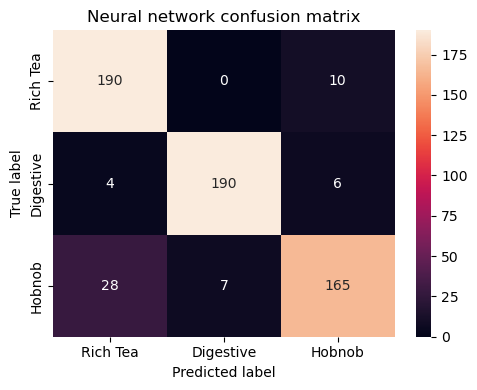

              precision    recall  f1-score   support

    Rich Tea       0.86      0.95      0.90       200
   Digestive       0.96      0.95      0.96       200
      Hobnob       0.91      0.82      0.87       200

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



In [26]:
nn_cm = confusion_matrix(y_test, nn_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    nn_cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Neural network confusion matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, nn_pred, target_names=class_names, zero_division=0))


# Classifying the microscopy data

Finally, I apply the trained neural network to the microscopy data. The same scaler from the dunking training data is used, so the microscopy rows are transformed consistently before prediction.


In [27]:
X_micro = micro[feature_cols]
X_micro_scaled = scaler.transform(X_micro)
X_micro_tensor = torch.tensor(X_micro_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    micro_logits = model(X_micro_tensor)
    micro_probs = torch.softmax(micro_logits, dim=1).cpu().numpy()
    micro_pred_idx = micro_probs.argmax(axis=1)

micro_predictions = micro.copy()
micro_predictions['predicted_index'] = micro_pred_idx
micro_predictions['predicted_biscuit'] = [reverse_label_map[i] for i in micro_pred_idx]
micro_predictions['prediction_confidence'] = micro_probs.max(axis=1)

for i, class_name in reverse_label_map.items():
    safe_class_name = class_name.replace(' ', '_')
    micro_predictions[f'prob_{safe_class_name}'] = micro_probs[:, i]

micro_predictions.to_csv('micro_predicted.csv', index=False)
micro_predictions.head()


,gamma,phi,eta,L,t,r,predicted_index,predicted_biscuit,prediction_confidence,prob_Rich_Tea,prob_Digestive,prob_Hobnob
0,0.084596,1.557367,0.000981,0.003221,24.231107,7.453712e-07,1,Digestive,0.562497,0.011782,0.562497,0.425722
1,0.064291,1.538842,0.000998,0.002395,22.169765,2.600680e-07,0,Rich Tea,0.926929,0.926929,0.000167,0.072904
2,0.086224,1.546138,0.001008,0.003036,23.257709,3.734618e-07,2,Hobnob,0.512540,0.475794,0.011665,0.512540
3,0.082859,1.566878,0.000997,0.001261,12.717432,7.567173e-07,1,Digestive,0.436796,0.190632,0.436796,0.372572
4,0.090832,1.570229,0.001002,0.000576,15.189146,8.239067e-07,0,Rich Tea,0.642484,0.642484,0.094931,0.262585


Two CSV files are produced by the final notebook:

- `neural_network_results.csv`: final neural-network metrics on the test set
- `micro_predicted.csv`: predicted biscuit classes for the microscopy data

The decision tree remains in the baseline comparison table only. The final method, final confusion matrix, and CSV outputs still use the neural network.
